## Converting a CFG to CNF
The following will be a conversion of a context-free grammar of any form into Chompsky Normal Form

This conversion has five steps:
1) Ensure the start variable is not on the RHS
2) Eliminate $\epsilon$-rules by first finding nullable variables
3) Eliminate unit rules
4) RHS is either one terminal or just variables
5) Ensure RHS has at most two variables

In [531]:
from copy import deepcopy

In [532]:
def display_grammar(grammar):
    for key in grammar:
        print(key, '->', ' | '.join(grammar[key]))

In [533]:
grammar = {
    "S":["AaB", "b"],
    "A":["S", "e", "AB"],
    "B":["bbb","ASA"],
}

display_grammar(grammar)

S -> AaB | b
A -> S | e | AB
B -> bbb | ASA


Step 1: Ensure the start variable is not on the RHS

In [534]:
# begin by adding S0 -> S to the grammar
grammar["S0"] = ["S"]

Step 2: Eliminate $\epsilon$-rules by first finding nullable variables

In [535]:
nullable_vars = []

# first, find the variables that can make e directly
for key in grammar:
    if "e" in grammar[key]:
        nullable_vars.append(key)

# Note, we'll need to include code for the indirect transformations eventually

For each appearance of the nullable variable in the grammar, add a rule where that variable is replaced by $\epsilon$

In [536]:
import itertools

def replace_chars(s, chars_to_replace, replacement_char):
    """
    Replaces characters in a string with a replacement character using itertools.

    Args:
        s: The input string.
        chars_to_replace: A list of characters to replace.
        replacement_char: The character to replace with.

    Returns:
        A list of strings with characters replaced.
    """
    indices_to_replace = [i for i, char in enumerate(s) if char in chars_to_replace]
    results = []

    if not indices_to_replace:
        return []

    max_replacements = len(indices_to_replace)

    for r in range(max_replacements + 1):
        for indices in itertools.combinations(indices_to_replace, r):
            new_s = list(s)
            for index in indices:
                new_s[index] = replacement_char
            results.append("".join(new_s))

    return results

In [537]:
for char in nullable_vars: # eliminate each variable that can make e directly
    for variable, rules in grammar.items():
        to_append = []

        for rule in rules:
            new_rules = replace_chars(rule, char, "")
            to_append.extend(new_rules)

        grammar[variable].extend(to_append)
        grammar[variable] = list(set(grammar[variable]))

Finally, remove all $\epsilon$ productions

In [538]:
for variable, rules in grammar.items():
    if "e" in rules:
        rules.remove("e")

In [539]:
display_grammar(grammar)

S -> b | aB | AaB
A -> B | AB | S
B -> AS | S | ASA | bbb | SA
S0 -> S


Step 3: Eliminate unit rules

In [540]:
# next, we make a graph for all unit rules
unit_rules = {}

for key in grammar:
    unit_rules[key] = []
    for rule in grammar[key]:
        if rule in grammar.keys():
            unit_rules[key].append(rule)

edges = []
for start, ends in unit_rules.items():
    for end in ends:
        edges.append((start, end))

display_grammar(unit_rules)

S -> 
A -> B | S
B -> S
S0 -> S


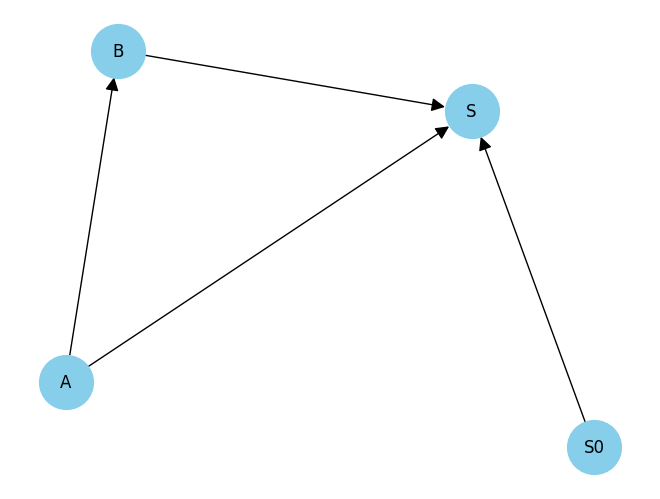

In [541]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_directed_graph(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    pos = nx.spring_layout(G)  # Layout mehod

    nx.draw(G, pos, with_labels=True, node_size=1500, node_color='skyblue', arrowsize=20)

    plt.show()

    return G

# Example usage
node_graph = visualize_directed_graph(edges)

In [542]:
# then, all rules that can be reached by unit rules
# have their rules added to the original variable
for v1, rule in grammar.items():
    for v2 in grammar.keys():
        if nx.has_path(node_graph, v1, v2):
            grammar[v1].extend(grammar[v2])
            grammar[v1] = list(set(grammar[v1]))

# then remove the unit rules
for variable, rule in grammar.items():
    grammar[variable] = [r for r in rule if r not in grammar.keys()]
display_grammar(grammar)

S -> b | aB | AaB
A -> b | AS | AaB | AB | ASA | bbb | SA | aB
B -> b | AS | ASA | bbb | AaB | SA | aB
S0 -> b | aB | AaB


Step 4: RHS is either one terminal or just variables

In [543]:
new_grammar = deepcopy(grammar)

for variable, rules in grammar.items():
    replacements = set()
    for rule in rules:
        # if a rule contains anything but single terminals,
        # replace those terminals with a variable
        if len(rule) == 1:
            continue
        for char in rule:
            if char.islower():
                replacements.add(rule)

    for rule in replacements:
        new_grammar[variable].remove(rule)

        result = ""
        for char in rule:
            if char.islower():
                new_grammar[f"[U{char}]"] = [char]
                result += f"[U{char}]"
            else:
                result += char

        new_grammar[variable].append(result)

grammar = deepcopy(new_grammar)

display_grammar(grammar)


S -> b | [Ua]B | A[Ua]B
A -> b | AS | AB | ASA | SA | [Ua]B | A[Ua]B | [Ub][Ub][Ub]
B -> b | AS | ASA | SA | [Ua]B | A[Ua]B | [Ub][Ub][Ub]
S0 -> b | [Ua]B | A[Ua]B
[Ua] -> a
[Ub] -> b


Step 5: Break up long RHS

In [ ]:
import re
import string

unused_characters = [x for x in string.ascii_uppercase if x not in grammar.keys()]

for variable, rules in grammar.items():

    for rule in rules:
        pattern = r'(\[[^\]]+\])|([^[]+?(?=\[|$))'
    
        # do some re matching to extract characters
        results = []
        for match in re.finditer(pattern, rule):
            if match.group(1):  # Bracketed content
                # Remove the brackets and add to results
                results.append(match.group(1))
            elif match.group(2):  # Non-bracketed content
                # Split non-bracketed content into individual characters
                for char in match.group(2):
                    results.append(char)

        if len(results) > 2:
            
            new_grammar[variable].remove(rule)
            new_rule = ""

            while len(results) > 2:
                a, b = results[:2]

                # add a new variable to the grammar which is the composite
                rhs = f"{a}{b}"

                # Find if this RHS already exists in the grammar
                var_found = None
                for v, r_list in new_grammar.items():
                    if rhs in r_list and len(r_list) == 1:
                        var_found = v
                        break
                
                # If not found, create a new variable
                if var_found is None:
                    var = unused_characters.pop(0)
                    new_grammar[var] = [rhs]
                else:
                    var = var_found
                
                # Update the rule under consideration
                results = results[2:]
                results.insert(0, var)

            new_rule = "".join(results)
            new_grammar[variable].append(new_rule)
            
       
display_grammar(new_grammar)

S -> b | [Ua]B | CB
A -> b | AS | AB | SA | [Ua]B | DA | CB | E[Ub]
B -> b | AS | SA | [Ua]B | DA | CB | E[Ub]
S0 -> b | [Ua]B | CB
[Ua] -> a
[Ub] -> b
C -> A[Ua]
D -> AS
E -> [Ub][Ub]


We have now converted a grammar into Chomsky normal form.